# 4 — The models, scored against the solver

Four descriptions of the same refraction, in increasing order of what they
throw away:

| model | interface | propagation |
|---|---|---|
| boundary-integral solution | exact BCs on the closed body | exact |
| tangent-plane on the cap | local plane wave + Fresnel | exact (surface representation) |
| Debye–Wolf from the ray pupil | ray amplitude $P=t_sd_2/d_1$ | large-Fresnel-number limit |
| thin element | phase screen at one plane | — (wavefront only) |

The first is the reference.  This notebook puts numbers on the other
three.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np, matplotlib.pyplot as plt
from nbstyle import *

from diffractor.optics import Medium, stigmatic_interface
from diffractor.analysis import two_leg_opl, invariant_opl

OV, AB, PO = load("ovoid_fields"), load("ovoid_fields_abs"), load("ovoid_po")
zi, zo = float(OV["zi"]), float(OV["zo"])
n1, n2, LAM = float(OV["n1"]), float(OV["n2"]), 1.0
k0, opl = float(OV["k0"]), float(OV["opl"])
inn = OV["th2"] <= float(OV["th2max"])

## Tangent-plane model versus the solver, on the exit sphere

amplitude: 12.3 % rms difference inside the rim
phase:     0.141 waves peak-to-valley, 0.052 waves rms


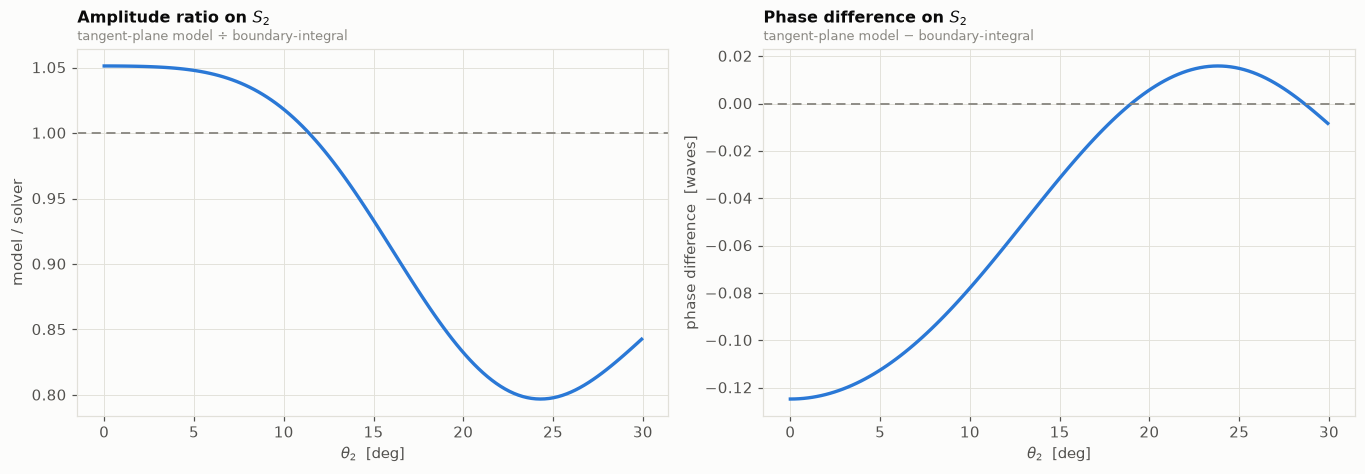

In [2]:
rms_amp = np.sqrt(np.mean((np.abs(PO["A2"][inn]) / np.abs(OV["A2"][inn]) - 1) ** 2))
dphi = np.angle(PO["A2"][inn] / OV["A2"][inn]) / (2 * np.pi)
print(f"amplitude: {100 * rms_amp:.1f} % rms difference inside the rim")
print(f"phase:     {np.ptp(dphi):.3f} waves peak-to-valley, "
      f"{np.std(dphi):.3f} waves rms")

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4))
t2 = np.degrees(OV["th2"][inn])
ax[0].plot(t2, np.abs(PO["A2"][inn]) / np.abs(OV["A2"][inn]), color=BLUE, lw=2.2)
ax[0].axhline(1.0, color=MUTED, lw=1.2, ls=(0, (5, 3)))
ax[0].set_xlabel(r"$\theta_2$  [deg]"); ax[0].set_ylabel("model / solver")
ttl(ax[0], "Amplitude ratio on $S_2$", "tangent-plane model ÷ boundary-integral")
ax[1].plot(t2, dphi, color=BLUE, lw=2.2)
ax[1].axhline(0.0, color=MUTED, lw=1.2, ls=(0, (5, 3)))
ax[1].set_xlabel(r"$\theta_2$  [deg]"); ax[1].set_ylabel("phase difference  [waves]")
ttl(ax[1], "Phase difference on $S_2$", "tangent-plane model − boundary-integral")
plt.tight_layout(); plt.show()

## Where the focus actually is

The Debye approximation replaces the diffraction integral by its
large-Fresnel-number limit, which puts the peak at the geometric image
point by construction.  Both the solver and the tangent-plane model put it
short of that.

In [3]:
z = OV["z_ax"]
rows = [("BEM, n₂ real", np.abs(OV["psi_ax"])),
        ("BEM, absorbing", np.abs(AB["psi_ax"])),
        ("tangent-plane", np.abs(PO["psi_ax"])),
        ("Debye–Wolf", np.abs(OV["dw_ax"]))]
for nm, y in rows:
    print(f"{nm:16s} axial peak at z = {z[y.argmax()]:.2f} λ  "
          f"(design {zi:.0f} λ)")
print(f"\naperture Fresnel number a²n₂/(λ z_i) = "
      f"{float(OV['r_rim'])**2 * n2 / zi:.2f}")

BEM, n₂ real     axial peak at z = 7.37 λ  (design 8 λ)
BEM, absorbing   axial peak at z = 7.37 λ  (design 8 λ)
tangent-plane    axial peak at z = 7.10 λ  (design 8 λ)
Debye–Wolf       axial peak at z = 8.01 λ  (design 8 λ)

aperture Fresnel number a²n₂/(λ z_i) = 1.66


## The thin-element model, as a function of scale

The thin-element (phase-screen) approximation keeps the ray height fixed
through the element and adds the optical thickness as a phase.  Its
wavefront error is measured here against the stigmatic constant, for the
same NA at a sequence of sizes.  Nothing else changes: scaling all lengths
with $\lambda$ fixed holds NA and changes only the size in wavelengths.

NA 0.750;  thin element: RMS = 5.86e-03 waves per λ of z_i
same measurement on the oval itself: RMS ≤ 2.5e-12 waves at every size
Maréchal (RMS = 1/14 wave) is reached at z_i ≈ 12 λ
for a 5 mm focal length at λ = 500 nm (z_i = 10⁴ λ): RMS ≈ 59 waves


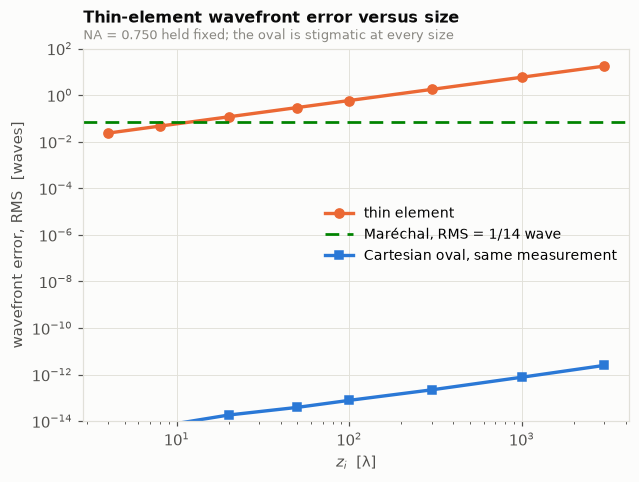

In [4]:
def thin_element_opd(zi_, n1=1.0, n2=1.5, i1_max_deg=80.0):
    zo_ = -2.0 * zi_
    g = stigmatic_interface(Medium(n1), Medium(n2), zo_, zi_).sample(
        4001, i1_max_deg=i1_max_deg)
    r, zs = g["r"], g["z"]
    zp = zs[-1]                                   # reference plane at the rim
    opl = (n1 * np.hypot(r, zp - zo_) + (n2 - n1) * (zp - zs)
           + n2 * np.hypot(r, zi_ - zp))
    opl = opl - opl[0]
    exact = two_leg_opl(n1, n2, r, zs, zo_, zi_)      # the real two-leg path
    exact = exact - invariant_opl(n1, n2, zo_, zi_)
    return np.ptp(opl), np.std(opl), np.std(exact), n2 * g["sin2"][-1]

sizes = np.array([4.0, 8.0, 20.0, 50.0, 100.0, 300.0, 1000.0, 3000.0])
pv, rms, rms_oval = np.transpose([thin_element_opd(s)[:3] for s in sizes])
na = thin_element_opd(8.0)[3]
slope = np.polyfit(sizes, rms, 1)[0]
print(f"NA {na:.3f};  thin element: RMS = {slope:.2e} waves per λ of z_i")
print(f"same measurement on the oval itself: RMS ≤ {rms_oval.max():.1e} waves "
      f"at every size")
print(f"Maréchal (RMS = 1/14 wave) is reached at z_i ≈ {1 / 14 / slope:.0f} λ")
print(f"for a 5 mm focal length at λ = 500 nm (z_i = 10⁴ λ): "
      f"RMS ≈ {slope * 1e4:.0f} waves")

fig, ax = plt.subplots(figsize=(6.4, 4.4))
ax.loglog(sizes, rms, "o-", color=ORANGE, lw=2.2, ms=6, label="thin element")
ax.axhline(1 / 14, color=GREEN, lw=1.8, ls=(0, (5, 3)),
           label="Maréchal, RMS = 1/14 wave")
ax.loglog(sizes, rms_oval, "s-", color=BLUE, lw=2.2, ms=5,
          label="Cartesian oval, same measurement")
ax.set_xlabel("$z_i$  [λ]"); ax.set_ylabel("wavefront error, RMS  [waves]")
ax.set_ylim(1e-14, 1e2); ax.legend(fontsize=9)
ttl(ax, "Thin-element wavefront error versus size",
    f"NA = {na:.3f} held fixed; the oval is stigmatic at every size")
plt.show()

## Summary of the measurements

Everything below is read off the runs in these notebooks.

In [5]:
P0 = float(np.abs(OV["A2_ray"][0]))
def relph(A):
    p = np.unwrap(np.angle(np.asarray(A) * np.exp(-1j * k0 * opl)))
    return (p - p[0]) / (2 * np.pi)

print(f"{'':28s}{'A(0)/P(0)':>11}{'A(rim)/P(0)':>13}{'phase PV':>11}")
# each row scaled by its own ray pupil on the axis
for nm, A, D in (("boundary-integral, n₂ real", OV["A2"], OV),
                 ("boundary-integral, absorbing", AB["A2"], AB),
                 ("tangent-plane on the cap", PO["A2"], OV),
                 ("Debye–Wolf from P", OV["A2_dw"], OV)):
    r = np.abs(A)[inn] / float(np.abs(D["A2_ray"][0]))
    print(f"{nm:28s}{r[0]:11.3f}{r[-1]:13.3f}{np.ptp(relph(A)[inn]):9.3f} w")
print(f"{'ray pupil P = t_s d₂/d₁':28s}{1.0:11.3f}"
      f"{float(OV['A2_ray'][inn][-1] / OV['A2_ray'][0]):13.3f}{0.0:9.3f} w")
print(f"{'constant amplitude':28s}{1.0:11.3f}{1.0:13.3f}{0.0:9.3f} w")

                              A(0)/P(0)  A(rim)/P(0)   phase PV
boundary-integral, n₂ real        0.943        0.286    0.084 w
boundary-integral, absorbing      0.911        0.361    0.058 w
tangent-plane on the cap          0.991        0.241    0.140 w
Debye–Wolf from P                 0.852        0.263    0.180 w
ray pupil P = t_s d₂/d₁           1.000        0.209    0.000 w
constant amplitude                1.000        1.000    0.000 w


**What holds.** The exit wavefront is spherical about A′ to under a
tenth of a wave — the stigmatic phase is real.  The amplitude on that
wavefront is not constant; it falls by roughly a factor of four across this
aperture, close to the ray pupil $P=t_sd_2/d_1$, and a constant-amplitude
field would carry a different total power through the same sphere.

**What the models cost.** The tangent-plane model reproduces the solver on
$S_2$ to about 12 % rms in amplitude at this size, with no fitted parameter.
The Debye–Wolf shortcut misplaces the focus here because the aperture
Fresnel number is of order one.  The thin-element model is diffraction
limited only for a lens a few wavelengths across.

**What is still open.** The closed body needed by the boundary-integral
formulation is a resonator; absorption is a numerical device, not the
physics we want.  A clean measurement of the pupil factor needs an
open-surface formulation, with the field jumps as unknowns and the
$\rho^{1/2}$ edge behaviour built in.